### Rudraksh Sindwani                          SIT720


# Part B: Problem Solving Practical Task

## Question 1: Linear SVM

### Discussion

The Bank Marketing dataset was loaded to predict whether a customer subscribed to a term deposit. The target variable `y` has two classes: yes and no.

The dataset contains numerical and categorical variables. The categorical variables were changed into numerical values using One-Hot Encoding. The data was divided into training and testing sets using stratified sampling because the target classes are not balanced. Standard Scaling was then applied to the features.

A Support Vector Machine with a linear kernel and the default value of `C = 1.0` was used. Accuracy precision recall and F1-score were used to measure the model performance.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bank = pd.read_csv("bank-additional-full.csv", sep=";")
print("\nTarget variable:")
print(bank["y"].value_counts())


Target variable:
y
no     36548
yes     4640
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = bank.drop("y", axis=1)
y = bank["y"].map({"no": 0, "yes": 1})

# One-Hot Encoding
Xencoded = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", Xencoded.shape[1])

# Split data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    Xencoded,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training samples:", Xtrain.shape[0])
print("Testing samples:", Xtest.shape[0])


# Standard Scaling
sc = StandardScaler()
sc.fit(Xtrain)

X_train_std = sc.transform(Xtrain)
X_test_std = sc.transform(Xtest)

print("Scaled training shape:", X_train_std.shape)
print("Scaled testing shape:", X_test_std.shape)

Features after encoding: 53
Training samples: 32950
Testing samples: 8238
Scaled training shape: (32950, 53)
Scaled testing shape: (8238, 53)


In [30]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

# Linear SVM with default C = 1.0
svm_linear = SVC(kernel="linear",C=1.0,random_state=0)

# Train model
svm_linear.fit(X_train_std, ytrain)

# Predictions
ypred = svm_linear.predict(X_test_std)

# Performance metrics
accuracy = accuracy_score(ytest, ypred)
precision = precision_score(ytest, ypred)
recall = recall_score(ytest, ypred)
f1 = f1_score(ytest, ypred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, ypred))

Accuracy: 0.9031318281136198
Precision: 0.6504629629629629
Recall: 0.30280172413793105
F1-score: 0.41323529411764703

Confusion Matrix:
[[7159  151]
 [ 647  281]]


In [31]:
# Use scaled data for the SVM models
Xtrain = X_train_std
Xtest = X_test_std

## Result

The Linear SVM model with the default C = 1.0 achieved an accuracy of 90.31%. The precision was 65.05% and the recall was 30.28%. The F1 score was 41.32%.

The confusion matrix shows that the model correctly classified 7159 customers who did not subscribe and 281 customers who subscribed. However 647 customers who subscribed were incorrectly classified as not subscribing.

The model has high accuracy but low recall. This happens because the dataset has many more customers who did not subscribe than customers who subscribed. The model therefore needs further improvement for detecting the smaller class.

# Question 2: Testing Different C Values

## Discussion

The C value controls the balance between a large margin and classification errors. A large C gives more importance to correctly classifying the training data. A small C allows more errors so the model can keep a larger margin.

Different C values were tested using the same training and testing data from Question 1. Accuracy and F1 score were used to compare the models. The C value with the best F1 score was selected as the optimal value.

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Different C values
C_values = [ 0.1,1, 10]
results = []

for c in C_values:
    model = SVC(kernel="linear",C=c,random_state=0,cache_size=2000)
    
    model.fit(Xtrain, ytrain)
    ypred_c = model.predict(Xtest)
    
    accuracy_c = accuracy_score(ytest, ypred_c)
    f1_c = f1_score(ytest, ypred_c)
    results.append([c, accuracy_c, f1_c])

results_df = pd.DataFrame(results,columns=["C", "Accuracy", "F1-score"])
print(results_df)

# Find the best C using F1score
best_index = results_df["F1-score"].idxmax()
best_C = results_df.loc[best_index, "C"]
print("\nBest C:", best_C)
print("Best F1-score:",results_df.loc[best_index, "F1-score"])

      C  Accuracy  F1-score
0   0.1  0.903010  0.410332
1   1.0  0.903132  0.413235
2  10.0  0.903132  0.413235

Best C: 1.0
Best F1-score: 0.41323529411764703


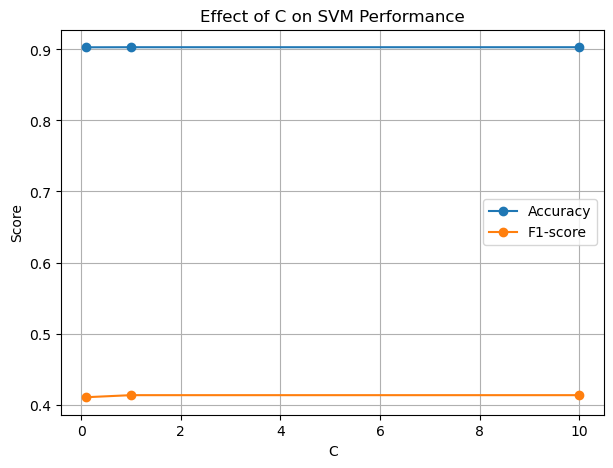

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(results_df["C"],results_df["Accuracy"], marker="o",label="Accuracy")
plt.plot(results_df["C"],results_df["F1-score"],marker="o",label="F1-score")
plt.xlabel("C")
plt.ylabel("Score")
plt.title("Effect of C on SVM Performance")
plt.legend()
plt.grid(True)
plt.show()

      C    Margin
0   0.1  1.223125
1   1.0  1.169066
2  10.0  1.163540


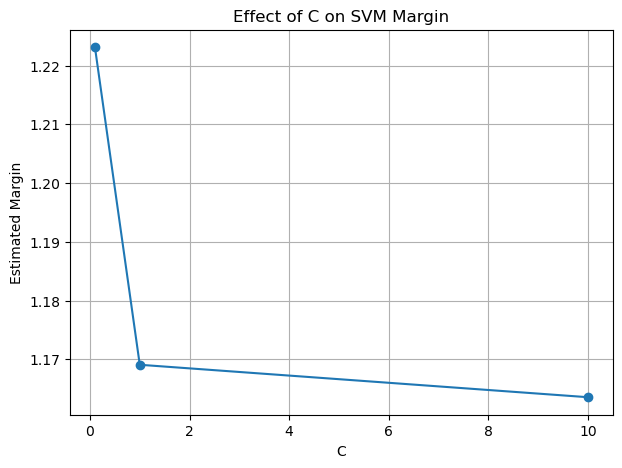

In [34]:
from sklearn.svm import LinearSVC

margin_results = []

for c in C_values:
    model = LinearSVC(C=c,random_state=0,max_iter=5000)

    model.fit(Xtrain, ytrain)
    w = model.coef_[0]
    margin = 1 / np.linalg.norm(w)

    margin_results.append([c, margin])

margin_df = pd.DataFrame(margin_results,columns=["C", "Margin"])
print(margin_df)

plt.figure(figsize=(7, 5))
plt.plot(margin_df["C"],margin_df["Margin"],marker="o")
plt.xlabel("C")
plt.ylabel("Estimated Margin")
plt.title("Effect of C on SVM Margin")
plt.grid(True)
plt.show()

## Result

Different C values were tested to compare the SVM performance. The best F1 score was 0.413 when C was 1.0. This was the same as the default C value used in Question 1.

The accuracy was 0.903 for all three C values. However the F1 score was highest at C = 1.0 with a value of 0.413. Therefore C = 1.0 was selected as the optimal C value.

The estimated margin was 1.223 for C = 0.1 1.169 for C = 1.0 and 1.164 for C = 10. The plot shows that the margin became smaller when C increased. Since the optimal C was the same as the default C there was no change in the margin from Question 1.


# Question 3: RBF and Polynomial Kernels

## Discussion

In this question the RBF and Polynomial kernels are tested using the same training and testing data. The RBF kernel can create a curved boundary when the data is not easy to separate with a straight line. The Polynomial kernel can also create a curved boundary based on its degree.

Different values of C and gamma are tested for the RBF kernel. Different values of C and degree are tested for the Polynomial kernel. The F1score is used to compare the models because the Bank Marketing dataset has an uneven class distribution.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Take a smaller balanced sample from training data for tuning
X_tune, _, y_tune, _ =train_test_split(Xtrain,ytrain,train_size=8000,random_state=0,stratify=ytrain)

print("Tuning data:",X_tune.shape)

# RBF tuning
C_values =[0.1, 1, 10]
gamma_values =["scale", 0.1]
rbf_results =[]

for c in C_values:
    for gamma in gamma_values:

        model=SVC(kernel="rbf",C=c,gamma=gamma,cache_size=2000)
        model.fit(X_tune, y_tune)

        ypred_rbf=model.predict(Xtest)

        accuracy =accuracy_score(ytest,ypred_rbf)
        f1 =f1_score(ytest, ypred_rbf)

        rbf_results.append([c,gamma, accuracy,f1])

rbf_df = pd.DataFrame(rbf_results,columns=["C","Gamma", "Accuracy","F1-score"])
print(rbf_df)

best_rbf_index =rbf_df["F1-score"].idxmax()
best_rbf= rbf_df.loc[best_rbf_index]

print("\nBest RBF setting:")
print(best_rbf)

Tuning data: (8000, 53)
      C  Gamma  Accuracy  F1-score
0   0.1  scale  0.890507  0.149057
1   0.1    0.1  0.887351  0.000000
2   1.0  scale  0.903617  0.443198
3   1.0    0.1  0.889415  0.139754
4  10.0  scale  0.892450  0.478210
5  10.0    0.1  0.887109  0.280186

Best RBF setting:
C              10.0
Gamma         scale
Accuracy    0.89245
F1-score    0.47821
Name: 4, dtype: object


In [36]:
# Polynomial kernel tuning
degree_values=[2, 3]
C_values =[0.1,1, 10]

poly_results = []

for c in C_values:
    for degree in degree_values:

        model=SVC(kernel="poly",C=c,degree=degree,gamma="scale",cache_size=2000)
        model.fit(X_tune, y_tune)

        ypred_poly =model.predict(Xtest)

        accuracy=accuracy_score(ytest,ypred_poly)
        f1 =f1_score(ytest, ypred_poly)

        poly_results.append([c, degree,accuracy,f1])

poly_df=pd.DataFrame(poly_results,columns=["C","Degree","Accuracy","F1-score"])
print(poly_df)

best_poly_index =poly_df["F1-score"].idxmax()
best_poly =poly_df.loc[best_poly_index]

print("\nBest Polynomial setting:")
print(best_poly)

      C  Degree  Accuracy  F1-score
0   0.1       2  0.895606  0.293924
1   0.1       3  0.895970  0.284043
2   1.0       2  0.898034  0.379616
3   1.0       3  0.898398  0.393917
4  10.0       2  0.892935  0.416667
5  10.0       3  0.892814  0.478441

Best Polynomial setting:
C           10.000000
Degree       3.000000
Accuracy     0.892814
F1-score     0.478441
Name: 5, dtype: float64


In [37]:
# Train the best models using the full training data

# Linear SVM
linear_best=SVC(kernel="linear",C=1.0,random_state=0,cache_size=2000)

linear_best.fit(Xtrain, ytrain)
ypred_linear=linear_best.predict(Xtest)

# RBF SVM
rbf_best=SVC(kernel="rbf",C=10.0,gamma="scale",random_state=0,cache_size=2000)

rbf_best.fit(Xtrain,ytrain)
ypred_rbf=rbf_best.predict(Xtest)

# Polynomial SVM
poly_best =SVC(kernel="poly",C=10.0,degree=3,gamma="scale",random_state=0,cache_size=2000)

poly_best.fit(Xtrain, ytrain)
ypred_poly=poly_best.predict(Xtest)

# Final comparison on the test set
print("Linear SVM")
print("Accuracy:",accuracy_score(ytest, ypred_linear))
print("F1-score:",f1_score(ytest, ypred_linear))

print("\nRBF SVM")
print("Accuracy:",accuracy_score(ytest, ypred_rbf))
print("F1-score:",f1_score(ytest, ypred_rbf))

print("\nPolynomial SVM")
print("Accuracy:",accuracy_score(ytest, ypred_poly))
print("F1-score:",f1_score(ytest, ypred_poly))

Linear SVM
Accuracy: 0.9031318281136198
F1-score: 0.41323529411764703

RBF SVM
Accuracy: 0.9017965525613013
F1-score: 0.4946908182386009

Polynomial SVM
Accuracy: 0.8985190580237922
F1-score: 0.48074534161490684


## Result

Different values of C and gamma were tested for the RBF kernel. The best RBF setting was C =10 and gamma = scale. It gave an accuracy of 89.25% and an F1 score of 47.82% during tuning.

For the Polynomial kernel different values of C and degree were tested. The best setting was C =10 and degree = 3. It gave an accuracy of 89.28% and an F1 score of 47.84% during tuning.

After training the selected models on the full training data the RBF SVM gave an accuracy of 90.18% and an F1 score of 49.47%. The Polynomial SVM gave an accuracy of 89.85% and an F1 score of 48.07%. The Linear SVM gave an accuracy of 90.31% and an F1 score of 41.32%.

The RBF kernel had the highest F1 score. This shows that the RBF kernel was better at finding customers who subscribed to a term deposit than the Linear and Polynomial kernels.

# Question 4: Support Vectors

## Discussion

The best SVM model from Question 3 was the Linear SVM with C = 1.0. Support vectors are the data points closest to the decision boundary. These points are important because they help the SVM decide the position of the boundary and the margin.

The number of support vectors was checked for each class. A larger number of support vectors means that more data points are close to the decision boundary.

In [38]:
# Number of support vectors for each class
print("Support vectors for each class:")
print(linear_best.n_support_)

# Total number
total_support_vectors = linear_best.n_support_.sum()
print("\nTotal support vectors:", total_support_vectors)

Support vectors for each class:
[3305 3285]

Total support vectors: 6590


## Result

The best model from Question 3 was the RBF SVM. It had 6590 support vectors in total. There were 3305 support vectors from class 0 and 3285 from class 1.

Support vectors are the data points that are close to the decision boundary. They are important because they help the SVM find the boundary between the two classes. The number of support vectors in both classes is very close in this model.

# Question 5: Handling Class Imbalance

## Discussion

The Bank Marketing dataset has many more customers who did not subscribe than customers who subscribed. This class imbalance can make the model focus more on the larger class.

To deal with this problem `class_weight="balanced"` was used with the RBF SVM. This gives more importance to the smaller class. The balanced model was then compared with the original RBF SVM using accuracy precision recall and F1 score.

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# RBF SVM with balanced class weights
rbf_balanced = SVC(kernel="rbf",C=10,gamma="scale",class_weight="balanced",random_state=0,cache_size=2000)

# Train the balanced model
rbf_balanced.fit(Xtrain, ytrain)

# Prediction
ypred_balanced = rbf_balanced.predict(Xtest)

# Performance
accuracy_balanced = accuracy_score(ytest, ypred_balanced)
precision_balanced = precision_score(ytest, ypred_balanced)
recall_balanced = recall_score(ytest, ypred_balanced)
f1_balanced = f1_score(ytest, ypred_balanced)

print("Balanced RBF SVM")
print("Accuracy:", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall:", recall_balanced)
print("F1-score:", f1_balanced)

Balanced RBF SVM
Accuracy: 0.8739985433357611
Precision: 0.4613220815752461
Recall: 0.7068965517241379
F1-score: 0.5582978723404255


## Result

The RBF SVM was used with balanced class weights to deal with the class imbalance in the dataset. The balanced model achieved an accuracy of 87.40%. Its precision was 46.13% and its recall was 70.69%. The F1-score was 55.83%.

Compared with the original RBF SVM the accuracy became lower. However the F1-score increased from 49.47% to 55.83%. This shows that the balanced model was better at finding customers who subscribed to a term deposit.

Overall the balanced RBF SVM gave more attention to the smaller class. This can be useful for the bank because finding customers who may subscribe is important.

# Question 6: Reflection on SVM for the Bank Marketing Dataset

## Discussion

The results from Questions 1 to 5 show that SVM can be used for the Bank Marketing dataset. Changing the C value affected the model results. The best C value for the linear SVM was 1.0 because it gave the best F1 score.

The kernel also changed the model performance. The RBF kernel gave the highest F1 score among the three kernels. The Polynomial kernel also worked well but its F1 score was lower than the RBF kernel.

Class imbalance was a major problem in this dataset. The balanced RBF SVM had a lower accuracy but its F1 score increased from 49.47% to 55.83%. Its recall was 70.69%. This means the balanced model was better at finding customers who subscribed.

Overall SVM can be useful for this business problem. The balanced RBF SVM may be a better choice when finding possible subscribers is more important than getting the highest accuracy.

In [41]:
# Final SVM comparison

final_comparison = pd.DataFrame({
    "Model": ["Linear SVM","RBF SVM","Polynomial SVM","Balanced RBF SVM"],
    "Accuracy": [
        accuracy_score(ytest,ypred_linear),
        accuracy_score(ytest,ypred_rbf),
        accuracy_score(ytest,ypred_poly),
        accuracy_balanced
    ],
    "F1-score": [
        f1_score(ytest,ypred_linear),
        f1_score(ytest,ypred_rbf),
        f1_score(ytest,ypred_poly),
        f1_balanced
    ]
})
final_comparison

,Model,Accuracy,F1-score
0,Linear SVM,0.903132,0.413235
1,RBF SVM,0.901797,0.494691
2,Polynomial SVM,0.898519,0.480745
3,Balanced RBF SVM,0.873999,0.558298


## Result

The results show that SVM can be used for the Bank Marketing dataset. Changing the C value affected the model performance. The best C value for the Linear SVM was 1.0.

Different kernels also gave different results. The Linear SVM had the highest accuracy of 90.31%. The RBF SVM had a higher F1 score of 49.47% than the Linear SVM. The Polynomial SVM had an F1 score of 48.07%.

Class imbalance was an important problem in this dataset. The Balanced RBF SVM had a lower accuracy of 87.40% but its F1 score increased to 55.83%. Its recall was 70.69%. This means the balanced model was better at finding customers who subscribed to a term deposit.

Overall the Balanced RBF SVM is more suitable when finding possible subscribers is more important than getting the highest accuracy. SVM can be useful for this business problem but class imbalance should be handled carefully.